In [1]:
from datasets import get_test_loader, synsetid_to_cate
import torch

import torch.nn as nn
from models.networks import PointFlow
from models.vae import BaseModel as VAE
from models.encoder import BaseModel as Encoder
from models.encoder_extended import BaseModel as EncoderExtended
from model_wrapper import TopologicalModelVAE, TopologicalModelEncoder, ShapeNetModel, TopologicalModelEncoderScaled
from models.networks import PointFlow
from load_model_scaled import load_encoder
from args import get_parser

import  matplotlib.pyplot as plt
import umap
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from layers.ect import EctLayer, EctConfig
import pyvista as pv
pv.set_jupyter_backend('trame')

%matplotlib inline

In [2]:
# def evaluate_gen(model, args):
#     loader = get_test_loader(args)
#     all_sample = []
#     all_ref = []
#     for i, data in enumerate(loader):
#         idx_b, te_pc, tr_pc = data["idx"], data["test_points"], data["train_points"]
#         te_pc = te_pc.cuda() if args.gpu is None else te_pc.cuda(args.gpu)
#         B, N = te_pc.size(0), te_pc.size(1)
#         _, out_pc = model.sample(B, N)

#         # denormalize
#         m, s = data["mean"].float(), data["std"].float()
#         m = m.cuda() if args.gpu is None else m.cuda(args.gpu)
#         s = s.cuda() if args.gpu is None else s.cuda(args.gpu)
#         out_pc = out_pc * s + m
#         te_pc = te_pc * s + m

#         if args.normalize:
#             te_pc, _, _ = normalize(te_pc)
#             out_pc, _, _ = normalize(out_pc)

#         all_sample.append(out_pc)
#         all_ref.append(te_pc)


#         if args.fast_run and i==2:
#             break

#     sample_pcs = torch.cat(all_sample, dim=0)
#     ref_pcs = torch.cat(all_ref, dim=0)

#     # Compute metrics
#     results = compute_all_metrics(
#         sample_pcs, ref_pcs, args.batch_size, accelerated_cd=True
#     )
#     results = {
#         k: (v.cpu().detach().item() if not isinstance(v, float) else v)
#         for k, v in results.items()
#     }
#     return results, sample_pcs, ref_pcs


def load_model(args):
    # Load the model 
    if args.model == "Encoder": 
        print("Loading Encoder")
        encoder_model = Encoder.load_from_checkpoint(
            checkpoint_path=f"./trained_models/ectencoder_shapenet_{args.cates[0]}.ckpt"
        ).cuda()
        model = TopologicalModelEncoder(encoder_model.cuda())
    elif args.model == "EncoderExtended": 
        print("Loading EncoderExtended")
        encoder_model = EncoderExtended.load_from_checkpoint(
            checkpoint_path=f"./trained_models/ectencoder_shapenet_{args.cates[0]}_extended.ckpt"
        ).cuda()
        model = TopologicalModelEncoder(encoder_model.cuda())
    elif args.model == "EncoderScaled": 
        print("Loading EncoderScaled")
        path = f"./configs/config_encoder_shapenet_{args.cates[0]}_scaled.yaml"
        encoder = load_encoder(path)
        model = TopologicalModelEncoderScaled(encoder.cuda(),args.normalize)

    elif args.model == "EncoderScaledBase": 
        print("Loading EncoderScaledBase")
        path = f"./configs/config_encoder_shapenet_{args.cates[0]}_scaled_base.yaml"
        encoder = load_encoder(path)
        model = TopologicalModelEncoderScaled(encoder.cuda(),args.normalize)
    elif args.model == "VAE":
        print("Loading VAE")
        encoder_model = Encoder.load_from_checkpoint(
            checkpoint_path=f"./trained_models/ectencoder_shapenet_{args.cates[0]}.ckpt"
        ).cuda()
        vae = VAE.load_from_checkpoint(
            f"./trained_models/vae_shapenet_{args.cates[0]}.ckpt"
        ).cuda()
        model = TopologicalModelVAE(encoder_model, vae)
        model.vae.eval()
    elif args.model == "PointFlow":
        model = PointFlow(args)

        def _transform_(m):
            return nn.DataParallel(m, device_ids=[0])

        model = model.cuda()
        model.multi_gpu_wrapper(_transform_)

        print("Resume Path:%s" % args.resume_checkpoint)
        checkpoint = torch.load(args.resume_checkpoint)
        model.load_state_dict(checkpoint)
        model.eval()
    elif args.model == "ShapeNet-0":
        model = ShapeNetModel(noise=0)
    elif args.model == "ShapeNet-005":
        model = ShapeNetModel(noise=.005)
    elif args.model == "ShapeNet-01":
        model = ShapeNetModel(noise=.01)
    else: 
        raise ValueError()
    return model 



In [3]:
model = "VAE"
p = get_parser()
args, unknown = p.parse_known_args({"fast_run":False})
args.model = model
args.cates = ["chair"]
model = load_model(args)

Loading VAE


C:\Users\ernst\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\lightning\pytorch\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.3.3, which is newer than your current Lightning version: v2.2.3


In [4]:
print("=====GEN======")
loader = get_test_loader(args)
all_ect = []
all_recon_ect = []
tr_pcs = []
mus, lvs = [],[]
rc_pcs = []
with torch.no_grad():
    for data in loader:
        idx_b, tr_pc, te_pc = data["idx"], data["train_points"], data["test_points"]

        te_pc = te_pc.cuda() if args.gpu is None else te_pc.cuda(args.gpu)
        tr_pc = tr_pc.cuda() if args.gpu is None else tr_pc.cuda(args.gpu)
        B, N = te_pc.size(0), te_pc.size(1)
        recon_ect, ect,mu,lv = model.reconstruct_vae(tr_pc, num_points=N)
        out_pc = model.reconstruct(tr_pc, num_points=N)
        mus.append(mu)
        lvs.append(lv)
        all_ect.append((ect + 1 ) / 2)
        all_recon_ect.append((recon_ect + 1 ) / 2)
        tr_pcs.append(tr_pc)
        rc_pcs.append(out_pc)

ref_ect = torch.cat(all_ect, dim=0)
recon_ect = torch.cat(all_recon_ect, dim=0)
ref_pcs =torch.cat(tr_pcs,dim=0)
recon_pcs = torch.cat(rc_pcs,dim=0)


=====GEN======
Total number of data:4612
Min number of points: (train)2048 (test)2048
Total number of data:662
Min number of points: (train)2048 (test)2048


In [40]:
latent_vector = torch.cat(mus,dim=0).cpu().numpy()
logvar_vector = torch.cat(lvs,dim=0).cpu().numpy()


# mu_v = torch.cat(mus,dim=0).cpu()
# lv_v = torch.cat(lvs,dim=0).cpu()
# with torch.no_grad():
#     latent_vector = model.vae.model.reparameterize(mu_v, lv_v)

# Embed paths from the ambient space into the latent space 

We interpolate between ect's and map them to the latent space

In [41]:
def plot_pcs_recon(ref_pcs,sample_pcs,offset=0):
    jnt_pcs = torch.cat([ref_pcs,sample_pcs],dim=1)
    
    pl = pv.Plotter(shape=(3,10), window_size=[1200, 600],border=False,polygon_smoothing=True)

    for col in range(10):
        points = ref_pcs[col+offset].reshape(-1, 3).detach().cpu().numpy()
        pl.subplot(0, col)
        actor = pl.add_points(
            points,
            style="points",
            emissive=False,
            show_scalar_bar=False,
            render_points_as_spheres=True,
            scalars=points[:, 2],
            point_size=2,
            ambient=0.2, 
            diffuse=0.8, 
            specular=0.8,
            specular_power=40, 
            smooth_shading=True
        )
        points = sample_pcs[col+offset].reshape(-1, 3).detach().cpu().numpy()
        pl.subplot(1, col)
        actor = pl.add_points(
            points,
            style="points",
            emissive=False,
            show_scalar_bar=False,
            render_points_as_spheres=True,
            scalars=points[:, 2],
            point_size=2,
            ambient=0.2, 
            diffuse=0.8, 
            specular=0.8,
            specular_power=40, 
            smooth_shading=True
        )
        points = jnt_pcs[col+offset].reshape(-1, 3).detach().cpu().numpy()
        pl.subplot(2, col)
        actor = pl.add_points(
            points,
            style="points",
            emissive=False,
            show_scalar_bar=False,
            render_points_as_spheres=True,
            scalars=points[:, 2],
            point_size=2,
            ambient=0.2, 
            diffuse=0.8, 
            specular=0.8,
            specular_power=40, 
            smooth_shading=True
        )


    pl.background_color = "w"
    pl.link_views()
    pl.camera_position = "xy"
    pos = pl.camera.position
    pl.camera.position = (pos[0],pos[1]+3,pos[2])
    pl.camera.position = (1,0,0)
    pl.camera.azimuth = 45
    pl.camera.elevation = 30
    # create a top down light
    light = pv.Light(position=(0, 0, 0), positional=True,
                    cone_angle=50, exponent=20, intensity=.2)
    pl.add_light(light)
    pl.camera.zoom(1.3)
    pl.show()

In [42]:
plot_pcs_recon(ref_pcs[10:],recon_pcs[10:])

Widget(value='<iframe src="http://localhost:61979/index.html?ui=P_0x25a45a546d0_3&reconnect=auto" class="pyvis…

In [43]:
# START = 31
# END = 34
START = 18
END = 10

pl = pv.Plotter(shape=(1,2), window_size=[800, 400],border=False,polygon_smoothing=True)

points = ref_pcs[START].reshape(-1, 3).detach().cpu().numpy()
pl.subplot(0, 0)
actor = pl.add_points(
    points,
    style="points",
    emissive=False,
    show_scalar_bar=False,
    render_points_as_spheres=True,
    scalars=points[:, 2],
    point_size=2,
    ambient=0.2, 
    diffuse=0.8, 
    specular=0.8,
    specular_power=40, 
    smooth_shading=True
)
points = ref_pcs[END].reshape(-1, 3).detach().cpu().numpy()
pl.subplot(0, 1)
actor = pl.add_points(
    points,
    style="points",
    emissive=False,
    show_scalar_bar=False,
    render_points_as_spheres=True,
    scalars=points[:, 2],
    point_size=2,
    ambient=0.2, 
    diffuse=0.8, 
    specular=0.8,
    specular_power=40, 
    smooth_shading=True
)
pl.background_color = "w"
pl.link_views()
pl.camera_position = "xy"
pos = pl.camera.position
pl.camera.position = (pos[0],pos[1]+3,pos[2])
pl.camera.position = (20,0,0)
pl.camera.azimuth = 45
pl.camera.elevation = 30
# create a top down light
light = pv.Light(position=(0, 0, 0), positional=True,
                cone_angle=50, exponent=20, intensity=.2)
pl.add_light(light)
pl.camera.zoom(1.3)
pl.show()

Widget(value='<iframe src="http://localhost:61979/index.html?ui=P_0x2575ff274c0_4&reconnect=auto" class="pyvis…

In [44]:
with torch.no_grad():
    t = torch.tensor(np.linspace(0,1,100,endpoint=True)).view(-1,1,1).cuda()
    ect_interp = (t * ref_ect[START].repeat((100,1,1)) + (1-t) * ref_ect[END].repeat((100,1,1))).to(torch.float32)
    _,_,mu,lv = model.vae(ect_interp.unsqueeze(1))

    latent_path = mu
    latent_path_logvar = lv

# Plot Latent Space

In [45]:
import numpy as np
from sklearn.decomposition import PCA

<Axes: >

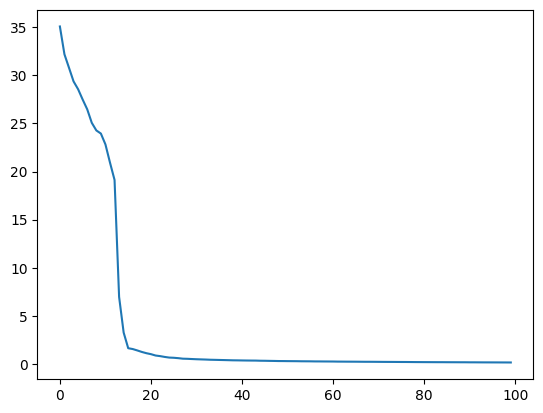

In [46]:
pca = PCA(n_components=100)
pca.fit(latent_vector)
mean_pca = pca.transform(latent_vector)
sv = pca.singular_values_
sns.lineplot(sv)

This indicates there are approx 10-15 principal components. 

In [47]:
# mean_latent_path = pca.transform(latent_path.cpu().numpy())


In [48]:
# import pandas as pd 
# import seaborn as sns

# latent_df = pd.DataFrame(mean_pca)
# latent_df["cls"] = 0
# mean_latent_path_df = pd.DataFrame(mean_latent_path)
# mean_latent_path_df["cls"] = 1
# df = pd.concat([latent_df, mean_latent_path_df])

In [13]:
# import matplotlib as mpl
# mpl.rcParams['lines.markersize'] = 2
# sns.pairplot(df,hue="cls")

# Plot the principal components

In [92]:
base = torch.nn.functional.one_hot(torch.arange(100),num_classes=100)
components = pca.inverse_transform(base)

In [93]:
base = torch.nn.functional.one_hot(torch.arange(100),num_classes=100)
components = pca.inverse_transform(base)
with torch.no_grad():
    ect_components = (model.vae.model.decode(torch.tensor(components).cuda().float()) + 1)/2

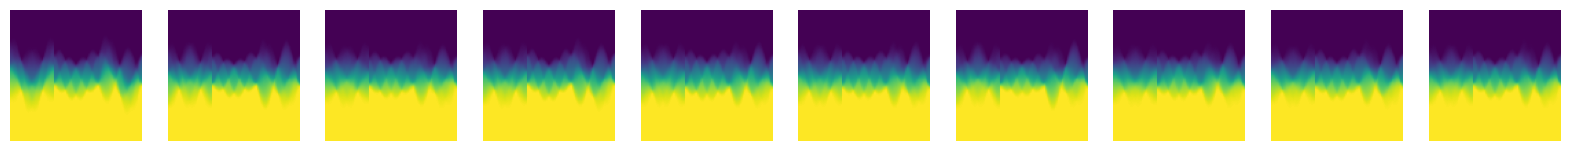

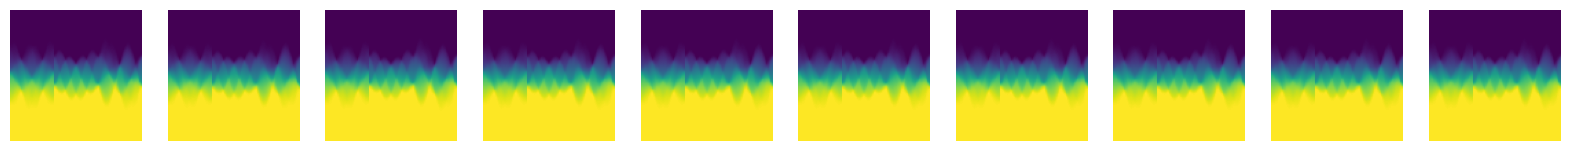

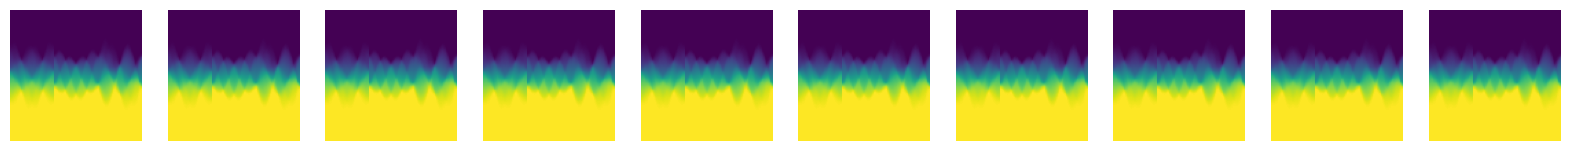

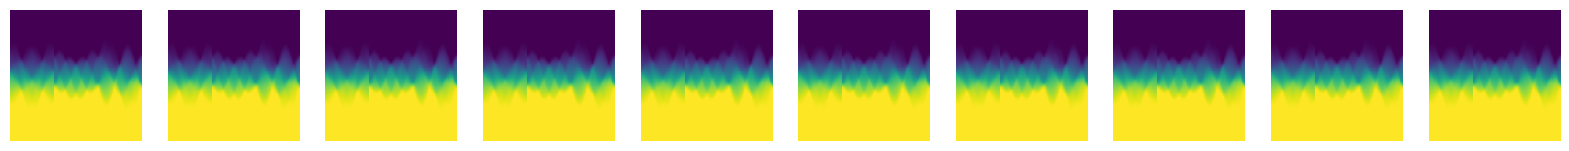

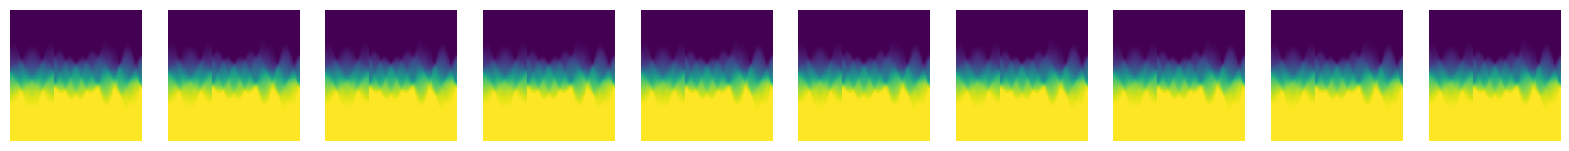

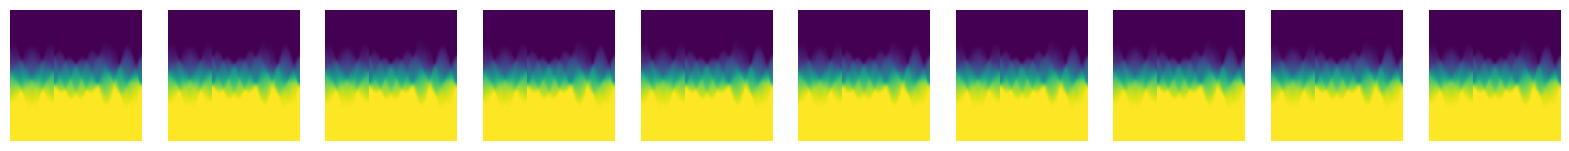

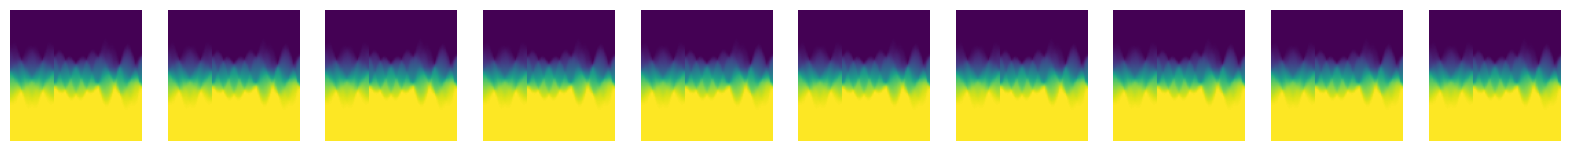

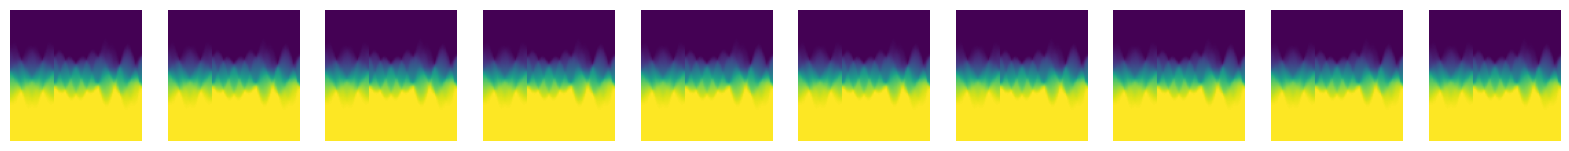

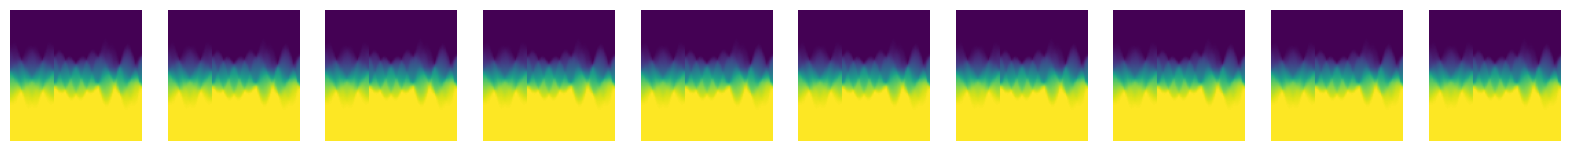

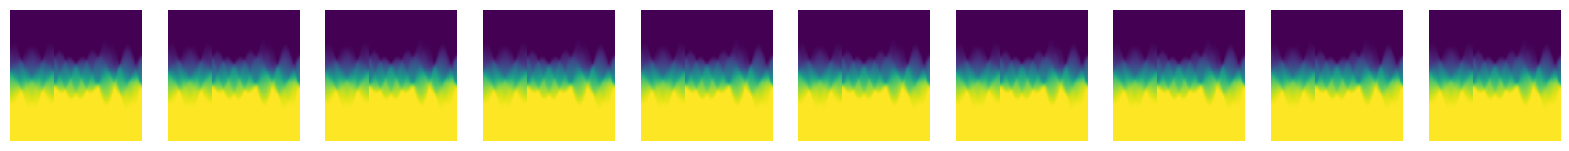

In [108]:
for j in range(10):
    fig, axes = plt.subplots(1,10,figsize=(20,4))
    for i in range(10):
        axes[i].imshow(ect_components[10*j +i].cpu().detach().cpu().squeeze())
        axes[i].axis("off")



In [97]:
ect_components.max()

tensor(1., device='cuda:0')

In [98]:
component_pcs = model.encoder(ect_components).view(-1,2048,3)

In [109]:
pl = pv.Plotter(shape=(1,10), window_size=[1600, 400],border=False,polygon_smoothing=True)
offset = 0
for col in range(10):
    points = component_pcs[col+offset].reshape(-1, 3).detach().cpu().numpy()
    pl.subplot(0, col)
    actor = pl.add_points(
        points,
        style="points",
        emissive=False,
        show_scalar_bar=False,
        render_points_as_spheres=True,
        scalars=points[:, 2],
        point_size=2,
        ambient=0.2, 
        diffuse=0.8, 
        specular=0.8,
        specular_power=40, 
        smooth_shading=True
    )

pl.background_color = "w"
pl.link_views()
pl.camera_position = "xy"
pos = pl.camera.position
pl.camera.position = (pos[0],pos[1]+3,pos[2])
pl.camera.position = (1,0,0)
pl.camera.azimuth = 45
pl.camera.elevation = 30
# create a top down light
light = pv.Light(position=(0, 0, 0), positional=True,
                cone_angle=50, exponent=20, intensity=.2)
pl.add_light(light)
pl.camera.zoom(1.3)
pl.show()

Widget(value='<iframe src="http://localhost:61979/index.html?ui=P_0x25a6b4b28f0_13&reconnect=auto" class="pyvi…

# Latent space ECT PCA 

In [112]:
ref_ect.shape

torch.Size([662, 96, 96])

<Axes: >

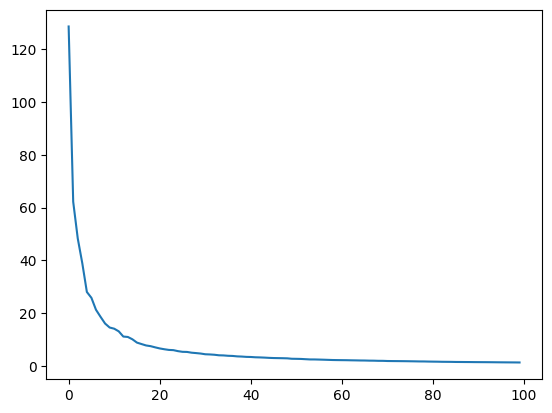

In [117]:
pca_ect = PCA(n_components=100)
pca_ect.fit(ref_ect.flatten(start_dim=1).cpu())
ect_projection = pca_ect.transform(ref_ect.flatten(start_dim=1).cpu())
sv = pca_ect.singular_values_
sns.lineplot(sv)

In [119]:
base = torch.nn.functional.one_hot(torch.arange(100),num_classes=100)
components = pca_ect.inverse_transform(base)
components.shape

(100, 9216)

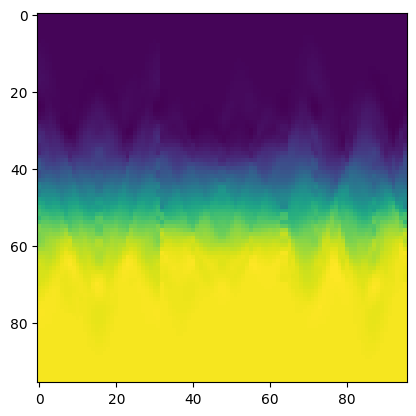

In [135]:
ect_base_components = torch.tensor(components).view(-1,96,96).cuda().float()

plt.imshow(ect_base_components[60].cpu().squeeze())

In [124]:
ect_pc = model.encoder(ect_base_components)


In [136]:
pl = pv.Plotter(shape=(1,10), window_size=[1600, 400],border=False,polygon_smoothing=True)
offset = 50
for col in range(10):
    points = ect_pc[col+offset].reshape(-1, 3).detach().cpu().numpy()
    pl.subplot(0, col)
    actor = pl.add_points(
        points,
        style="points",
        emissive=False,
        show_scalar_bar=False,
        render_points_as_spheres=True,
        scalars=points[:, 2],
        point_size=2,
        ambient=0.2, 
        diffuse=0.8, 
        specular=0.8,
        specular_power=40, 
        smooth_shading=True
    )

pl.background_color = "w"
pl.link_views()
pl.camera_position = "xy"
pos = pl.camera.position
pl.camera.position = (pos[0],pos[1]+3,pos[2])
pl.camera.position = (1,0,0)
pl.camera.azimuth = 45
pl.camera.elevation = 30
# create a top down light
light = pv.Light(position=(0, 0, 0), positional=True,
                cone_angle=50, exponent=20, intensity=.2)
pl.add_light(light)
pl.camera.zoom(1.3)
pl.show()

Widget(value='<iframe src="http://localhost:61979/index.html?ui=P_0x25a87a3bd30_16&reconnect=auto" class="pyvi…